Step 1: Load in necessary libraries and save all .csv files in a dictionary

Always load in necessary libraries 

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import minmax_scale
import os
import shutil
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf

In [ ]:
#Read in all .csv files and store them in a dictionary (dictionary is optional)

def read_csv_files(folder_path):
    dataframes = {}
    for file_name in os.listdir(folder_path):
        if file_name.endswith(".csv"):
            file_path = os.path.join(folder_path, file_name)
            dataframe = pd.read_csv(file_path, header=None)  # Set header=None to prevent the first row from being treated as header
            dataframes[file_name] = dataframe
    return dataframes

# Define the folder path 
folder_path_normal = #"/Users/natashakunchur/Desktop/Tunde Analysis/Normal/Normal csv" - replace with your actual path
folder_path_asthma = #"/Users/natashakunchur/Desktop/Tunde Analysis/Asthma/Asthma csv" - replace with your actual path
dataframe_normal = read_csv_files(folder_path_normal)
dataframe_asthma = read_csv_files(folder_path_asthma)

2. Cut the spectra to only contain the fingerprint region: 400cm-1 to 2000cm-1

In [ ]:
def filter_columns_by_x_axis(dataframe, lower_bound, upper_bound):
    # Extract the x-axis (first row of the .csv file)
    x_axis = dataframe.iloc[0, :]
    # Create a mask for columns within the desired range
    mask = (x_axis >= lower_bound) & (x_axis <= upper_bound)
    # Apply the mask to filter columns
    filtered_df = dataframe.loc[:, mask]
    return filtered_df

# Define the folder paths
input_folder = "/Users/natashakunchur/Desktop/Tunde Analysis/Normal/Normal csv" #- replace with your actual path
output_folder = "/Users/natashakunchur/Desktop/Tunde Analysis/Normal/Normal Filtered csv - fingerprint region" #- replace with your actual path
#input_folder = "/Users/natashakunchur/Desktop/Tunde Analysis/Asthma/Asthma csv" - replace with your actual path
#output_folder = "/Users/natashakunchur/Desktop/Tunde Analysis/Asthma/Asthma Filtered csv - fingerprint region" - replace with your actual path
os.makedirs(output_folder, exist_ok=True)  # Ensure the output folder exists

# Load all CSV files
dataframes = read_csv_files(input_folder)

# Process each DataFrame
for file_name, df in dataframes.items():
    filtered_df = filter_columns_by_x_axis(df, 400, 2000)
    
    # Save the filtered DataFrame to the output folder
    output_file = os.path.join(output_folder, f"{file_name}")
    filtered_df.to_csv(output_file, header=False, index=False)  # Save without headers or index
    print(f"Filtered data saved to: {output_file}")


Filtered data saved to: /Users/natashakunchur/Desktop/Tunde Analysis/Asthma/Asthma Filtered csv - fingerprint region/Scan LA--014--Sample 6-72h-asthma collagen fibronectin_spectra.csv
Filtered data saved to: /Users/natashakunchur/Desktop/Tunde Analysis/Asthma/Asthma Filtered csv - fingerprint region/Scan LA--011--Sample 3-72h-asthma collagen_spectra.csv
Filtered data saved to: /Users/natashakunchur/Desktop/Tunde Analysis/Asthma/Asthma Filtered csv - fingerprint region/Scan LA--007--Sample 1 24h Asthma Collagen_spectra.csv
Filtered data saved to: /Users/natashakunchur/Desktop/Tunde Analysis/Asthma/Asthma Filtered csv - fingerprint region/Scan LA--019--Sample 9-72h-asthma collagen fibronectin_spectra.csv
Filtered data saved to: /Users/natashakunchur/Desktop/Tunde Analysis/Asthma/Asthma Filtered csv - fingerprint region/Scan LA--023-- Sample 7- 24h athsma- collagen fibronectin_spectra.csv


3. Outlier removal using IQR method followed by min-max normalization

In [ ]:
# Function for replacing outlier (using IQR method)
def replace_outliers(df):
    for column in df.columns:
        # Calculate Q1, Q3 and IQR
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        
        # Define the lower and upper bounds for outliers
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Replace outliers with the median of the column
        median = df[column].median()
        df[column] = np.where((df[column] < lower_bound) | (df[column] > upper_bound), median, df[column])
        
    return df

#Function for Min-Max normalization
def min_max(df):
    # Exclude the first row (header) and normalize the rest of the data (starting from row 1)
    data_to_normalize = df.iloc[1:, :]  # Exclude the first row (header)
    # Check if there is any valid data to normalize
    if data_to_normalize.empty or data_to_normalize.isnull().all().all():
        print(f"No valid data to normalize in {df.columns[0]}...")
        return df  # Return the original dataframe if no valid data is present
    # Normalize across rows (axis=1 means normalize each row)
    normalized_data = minmax_scale(data_to_normalize, axis=1)  # Normalize each row
    # Convert the normalized data back to a DataFrame with the original columns
    df_normalized = pd.DataFrame(normalized_data, columns=df.columns)
    
    # Insert the first row (header) back to keep it as the header
    df_normalized.loc[-1] = df.iloc[0, :]  # Insert the first row (header) at the top
    df_normalized.index = df_normalized.index + 1  # Shift the index by 1
    df_normalized.sort_index(inplace=True)  # Sort the DataFrame by index
    df_normalized = df_normalized.drop(index=0)
    return df_normalized


# Define folder path for the original files
#input_folder = "/Users/natashakunchur/Desktop/Tunde Analysis/Normal/Normal Filtered csv - fingerprint region" - replace with your actual path
input_folder = "/Users/natashakunchur/Desktop/Tunde Analysis/Asthma/Asthma Filtered csv - fingerprint region" #- replace with your actual path

# Create output folder for normalized and outlier-corrected files
#output_folder = "/Users/natashakunchur/Desktop/Tunde Analysis/Normal/Normal filtered, outlier corrected and normalized"
output_folder = "/Users/natashakunchur/Desktop/Tunde Analysis/Asthma/Asthma filtered, outlier corrected and normalized" #- replace with your actual path
os.makedirs(output_folder, exist_ok=True)

# Iterate through all CSV files in the input folder
for filename in os.listdir(input_folder):
    if filename.endswith('.csv'):
        # Define the full path to the current CSV file
        file_path = os.path.join(input_folder, filename)
        # Read the CSV file into a DataFrame
        df = pd.read_csv(file_path)
        # Apply the outlier replacement
        df_outlier_corrected = replace_outliers(df.copy())
        # Apply Min-Max normalization
        df_normalized = min_max(df_outlier_corrected.copy())
        # Define the output file path with the name added at the end
        output_file_path = os.path.join(output_folder, f'{filename[:-4]}_normalized_outlier_corrected.csv')
        # Save the normalized and outlier-corrected DataFrame to a new CSV file
        df_normalized.to_csv(output_file_path, index=False)
        print(f'Processed file saved: {output_file_path}')

print('Processing complete for all CSV files.')


Processed file saved: /Users/natashakunchur/Desktop/Tunde Analysis/Asthma/Asthma filtered, outlier corrected and normalized/Scan LA--014--Sample 6-72h-asthma collagen fibronectin_spectra_normalized_outlier_corrected.csv
Processed file saved: /Users/natashakunchur/Desktop/Tunde Analysis/Asthma/Asthma filtered, outlier corrected and normalized/Scan LA--011--Sample 3-72h-asthma collagen_spectra_normalized_outlier_corrected.csv
Processed file saved: /Users/natashakunchur/Desktop/Tunde Analysis/Asthma/Asthma filtered, outlier corrected and normalized/Scan LA--007--Sample 1 24h Asthma Collagen_spectra_normalized_outlier_corrected.csv
Processed file saved: /Users/natashakunchur/Desktop/Tunde Analysis/Asthma/Asthma filtered, outlier corrected and normalized/Scan LA--019--Sample 9-72h-asthma collagen fibronectin_spectra_normalized_outlier_corrected.csv
Processed file saved: /Users/natashakunchur/Desktop/Tunde Analysis/Asthma/Asthma filtered, outlier corrected and normalized/Scan LA--023-- Sampl

4. Graph the spectra to validate if the normalization and outlier correction was good

In [ ]:
# Load the data with the correct header (do not use header=None)
#- replace with your actual path
df_filtered_outliercorected_normalized = pd.read_csv("ASthma/Asthma filtered, outlier corrected and normalized/Scan LA--019--Sample 9-72h-asthma collagen fibronectin_spectra_normalized_outlier_corrected.csv")

#Testing plotting
x_axis = df_filtered_outliercorected_normalized.iloc[0, :-1].index
data_rows = df_filtered_outliercorected_normalized.iloc[1:, :-1]

plt.figure(figsize= (40,5))

for index, row in data_rows.iterrows():
    plt.plot(x_axis, row.values)

plt.title('Test')
plt.xlabel('Raman Shift cm^{-1}')
plt.ylabel('Raman units (arb)')
#plt.grid(True)


5. Binary CNN Model using Sigmoid - ALL Asthma vs Control 

Load in necessary libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping


5a). Load in labelled dataset and split necessary

In [ ]:
# Load your CSV file
#- replace with your actual path
data = pd.read_csv("Test - collagen 24hr.csv")  # adjust path
data = data.drop(index=0).reset_index(drop=True)  # Drop first row (x-axis), reset index

# Assuming the last column is the label
X = data.iloc[:, :-1].values  # spectra
y = data.iloc[:, -1].values   # labels

# Standardize the spectra
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert labels to numeric if necessary
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y)

# Reshape for 1D CNN [samples, time steps, channels]
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]


5b). Model architecture

In [ ]:

model = Sequential([
    Conv1D(32, 7, activation='relu', input_shape=(389, 1)),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(64, 5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_3 (Conv1D)           (None, 383, 32)           256       
                                                                 
 batch_normalization_3 (Bat  (None, 383, 32)           128       
 chNormalization)                                                
                                                                 
 max_pooling1d_3 (MaxPoolin  (None, 191, 32)           0         
 g1D)                                                            
                                                                 
 conv1d_4 (Conv1D)           (None, 187, 64)           10304     
                                                                 
 batch_normalization_4 (Bat  (None, 187, 64)           256       
 chNormalization)                                                
                                                      

5c). Train the model
--> Add as many epochs as you like! I put 5 as a test - usually 100 is good. 

In [25]:
model_asthma_vs_control = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
241/241 [==============================] - 5s 17ms/step - loss: 0.0100 - accuracy: 0.9983 - val_loss: 0.6738 - val_accuracy: 0.7188
Epoch 2/5
241/241 [==============================] - 4s 17ms/step - loss: 0.0074 - accuracy: 0.9991 - val_loss: 0.1436 - val_accuracy: 0.9938
Epoch 3/5
241/241 [==============================] - 5s 19ms/step - loss: 6.4423e-04 - accuracy: 0.9999 - val_loss: 2.5015e-14 - val_accuracy: 1.0000
Epoch 4/5
241/241 [==============================] - 4s 18ms/step - loss: 2.6495e-13 - accuracy: 1.0000 - val_loss: 1.2745e-14 - val_accuracy: 1.0000
Epoch 5/5
241/241 [==============================] - 5s 19ms/step - loss: 9.7220e-14 - accuracy: 1.0000 - val_loss: 1.1588e-14 - val_accuracy: 1.0000


5d). Performance metrics 

76/76 [==============================] - 0s 5ms/step


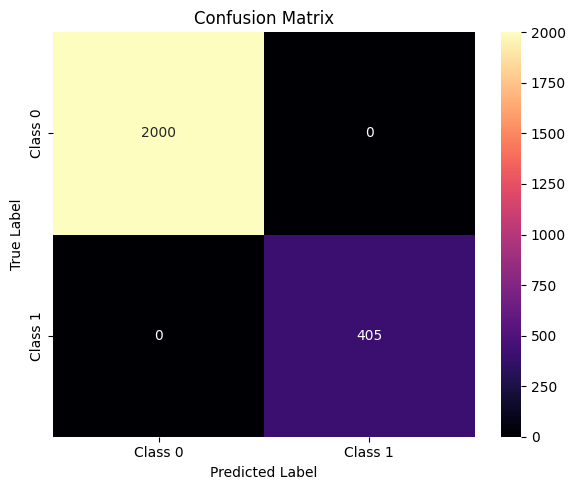

76/76 [==============================] - 0s 5ms/step


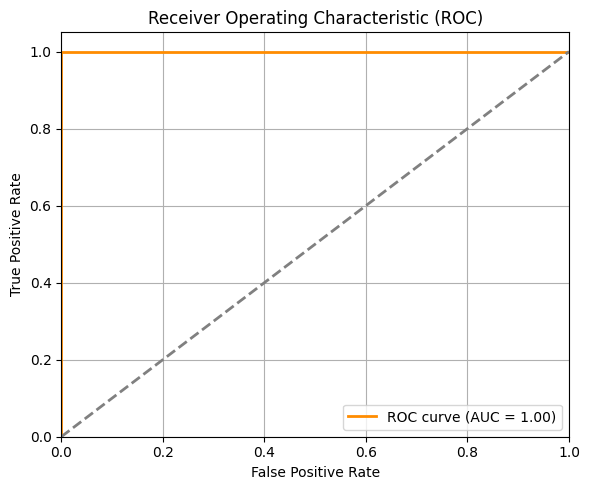

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00      2000
     Class 1       1.00      1.00      1.00       405

    accuracy                           1.00      2405
   macro avg       1.00      1.00      1.00      2405
weighted avg       1.00      1.00      1.00      2405



In [ ]:
# Predict on test data
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Optional: if you want percentage-style annotations
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', cbar=True,
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Predict probabilities (not class labels)
y_pred_prob = model.predict(X_test).ravel()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Generate classification report
print(classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"]))


6. Multi-class CNN Model - Using Softmax function 

6a. Load in labelled dataset and split necessary

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical

# Load CSV
data = pd.read_csv("Test2- multiclass collagen 24hr.csv", header=None)

# Drop x-axis row and reset index
data = data.drop(index=0).reset_index(drop=True)

# Split data
X = data.iloc[:, :-1].values.astype(float)
y = data.iloc[:, -1].values.astype(int)

# Standardize spectra
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# One-hot encode for softmax output
y_cat = to_categorical(y_encoded)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

# Reshape input for CNN
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]


6b. CNN Multi-class model architecture 

In [ ]:
# Model architecture
model = Sequential([
    Conv1D(32, 7, activation=None, kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1], 1)),
    LeakyReLU(alpha=0.01),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(64, 5, activation=None, kernel_regularizer=l2(0.001)),
    LeakyReLU(alpha=0.01),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, 3, activation=None, kernel_regularizer=l2(0.001)),
    LeakyReLU(alpha=0.01),
    BatchNormalization(),
    MaxPooling1D(2),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(6, activation='softmax')  ################# for multiclass
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)



6c. Train the model - put as many epochs as you would like. 

In [ ]:
# Train
model_intra_asthma = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30, #Put as many epochs as you like! 
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

6d. Performance Metrics on Model

In [ ]:
# Predict
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
labels = le.classes_  # original labels (1, 2, 3)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', cbar=True,
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

#Performance metrics report
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=[f"Class {label}" for label in labels]))

#ROC Cureve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# Binarize labels for ROC (one-hot format)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2,3,4,5])
n_classes = y_true_bin.shape[1]
# Plot ROC curves
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - One-vs-Rest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

